# Pipelines in Sklearn

## Prepare

In [5]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("ticks")
plt.rc("axes.spines", top=False, right=False)
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = False
plt.rcParams["grid.color"] = "white"

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [11]:
DATA_PATH = os.path.join("data", "titanic.csv")

In [13]:
np.random.randn(42)
random.seed(42)

## Import

In [16]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [18]:
train_df, test_df = train_test_split(df_raw, random_state=42)

## Inspect

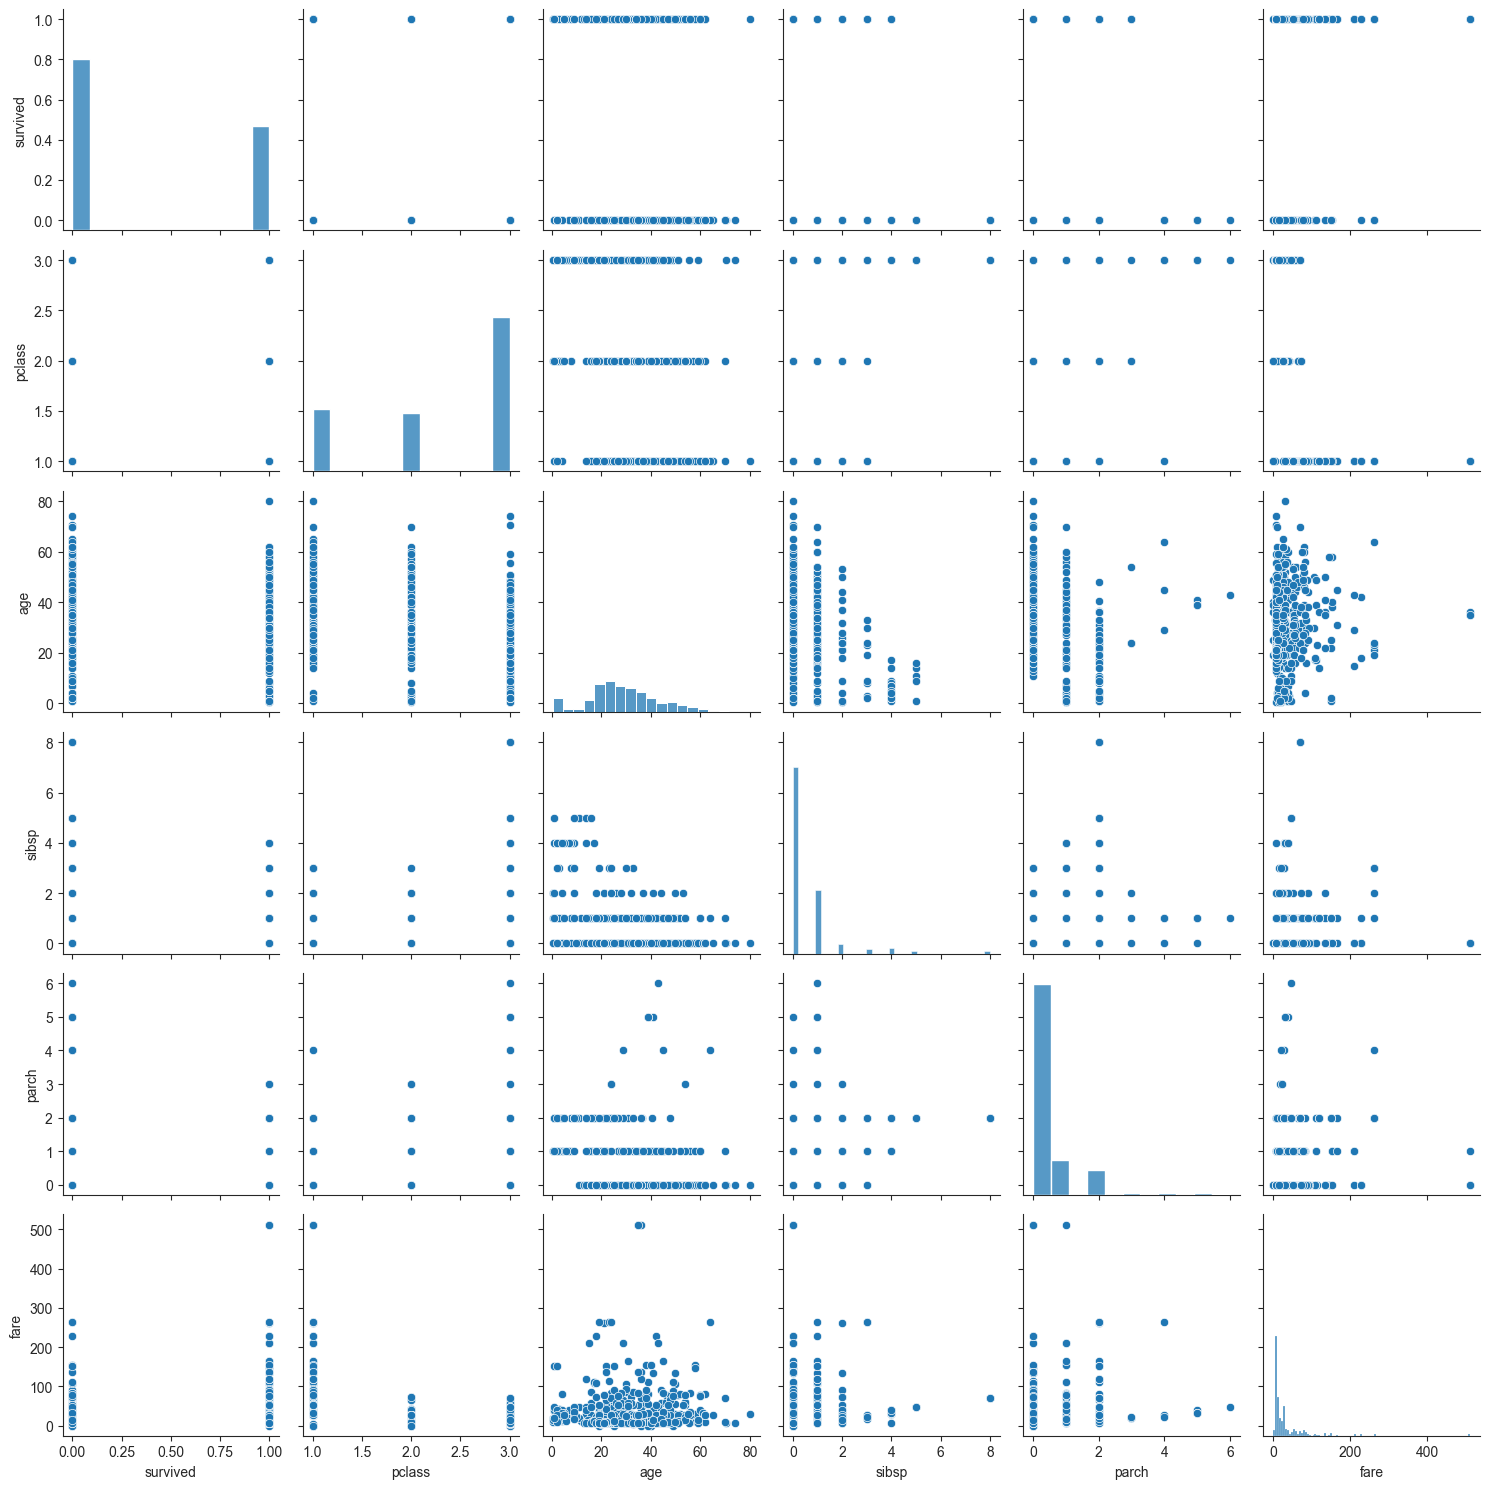

In [8]:
sns.pairplot(data=train_df)
plt.tight_layout()

<AxesSubplot:>

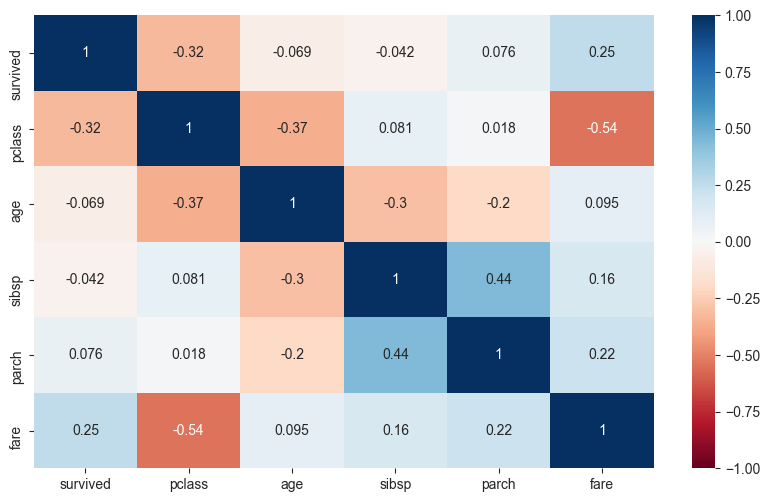

In [9]:
sns.heatmap(train_df.corr(), vmin=-1, vmax=1, cmap="RdBu", annot=True)

In [10]:
# Missing values
train_df.apply(lambda x: x.isnull().sum())

survived      0
pclass        0
name          0
sex           0
age         132
sibsp         0
parch         0
ticket        0
fare          0
cabin       519
embarked      2
dtype: int64

## Transform 1: einige Beispiele

In [11]:
temp = train_df.copy()
temp.shape

(668, 11)

### Umgang mit fehlenden Werten

1. Entitäten mit fehlenden Werten entfernen
2. Attribute mit fehlenden Werten entfernen
3. Fehlende Werte imputieren, also mit plausibelen Werten auffüllen

In [12]:
# Option 2
temp = temp.drop("cabin", axis=1)
temp.shape

(668, 10)

In [13]:
# Option 1
temp = temp.dropna()
temp.shape

(534, 10)

In [ ]:
# Option 1
# temp = temp.loc[temp["fare"] > 0]
# temp.shape

### Categoriale Variablen

Es gibt unterschiedliche Optionen, kategoriale Variablen in numerische Werte zu übersetzen.

In [14]:
temp["embarked"].value_counts()

S    422
C     91
Q     21
Name: embarked, dtype: int64

In [18]:
ordinal_encoder = OrdinalEncoder()
temp_encoded = ordinal_encoder.fit_transform(temp.loc[:, ["embarked"]])
temp_encoded[0:20]

array([[2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [0.],
       [2.],
       [2.],
       [0.],
       [1.],
       [2.],
       [2.],
       [2.],
       [0.],
       [2.],
       [2.],
       [2.],
       [2.]])

In [20]:
cat_encoder = OneHotEncoder()
temp_encoded = cat_encoder.fit_transform(temp.loc[:, ["embarked"]])
temp_encoded.toarray()[0:20]

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]])

### Feature scaling

Zwei Hauptoptionen:

- **Min-Max-Scaling:** Das Ergebnis ist eine Variable mit 0 als kleinstem und 1 als größtem Wert.
- **Standardization:** Das Ergebnis ist eine Variable mit einem Mittelwert von 0 und einer Varianz von 1

In [21]:
age = temp["age"].copy()

In [23]:
age_min_max = age - age.min()
age_min_max = age_min_max / age_min_max.max()

In [22]:
age_std = age - age.mean()
age_std = age_std / age_std.std()

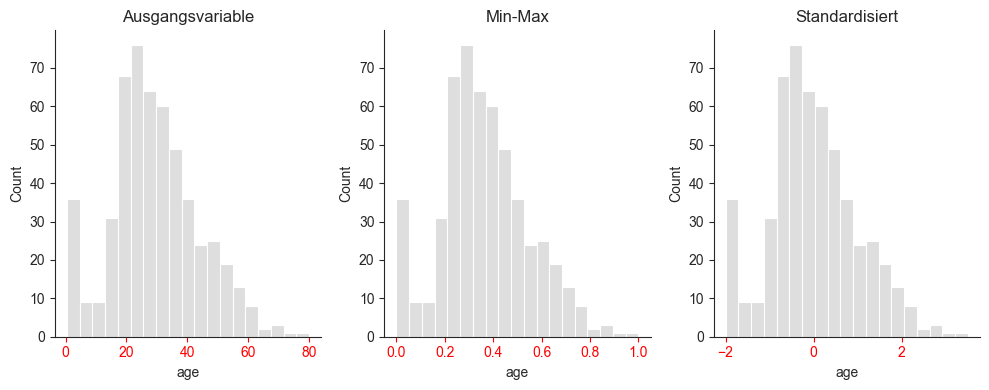

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4))
sns.histplot(age, ax=ax[0], color="lightgrey")
sns.histplot(age_min_max, ax=ax[1], color="lightgrey")
sns.histplot(age_std, ax=ax[2], color="lightgrey")
ax[0].set_title("Ausgangsvariable")
ax[1].set_title("Min-Max")
ax[2].set_title("Standardisiert")
for i in range(3):
    # ax[i].xaxis.label.set_color('blue')
    ax[i].tick_params(axis="x", colors="red")
plt.tight_layout()

## Transformation 2: rebuild as pipeline

In [53]:
num_attributes = ["sibsp", "parch", "age", "fare"]
train_df[num_attributes].head(2)

,sibsp,parch,age,fare
298,0,0,NaN,30.50
884,0,0,25.0,7.05


In [55]:
cat_attributes = ["sex", "embarked", "pclass"]
train_df[cat_attributes].head(2)

,sex,embarked,pclass
298,male,S,1
884,male,S,3


$\rightarrow$ **Designentscheidung:** Passagierklasse als numerische oder kategoriale Variable? Hier: kategorial

In [57]:
def prepare_for_pipeline(df):
    print("Original shape:", df.shape)
    df = df[num_attributes + cat_attributes + ["survived"]]
    print("Shape after feature selection:", df.shape)
    df = df.dropna()
    print("Shape after dropna():", df.shape)
    return df, df["survived"]

In [71]:
train_df_pre

,sibsp,parch,age,fare,sex,embarked,pclass,survived
884,0,0,25.00,7.0500,male,S,3,0
247,0,2,24.00,14.5000,female,S,2,1
478,0,0,22.00,7.5208,male,S,3,0
305,1,2,0.92,151.5500,male,S,1,1
316,1,0,24.00,26.0000,female,S,2,1
...,...,...,...,...,...,...,...,...
71,5,2,16.00,46.9000,female,S,3,0
106,0,0,21.00,7.6500,female,S,3,1
860,2,0,41.00,14.1083,male,S,3,0
435,1,2,14.00,120.0000,female,S,1,1


In [29]:
train_df_pre.head()

,sibsp,parch,age,fare,sex,embarked,pclass,survived
884,0,0,25.00,7.0500,male,S,3,0
247,0,2,24.00,14.5000,female,S,2,1
478,0,0,22.00,7.5208,male,S,3,0
305,1,2,0.92,151.5500,male,S,1,1
316,1,0,24.00,26.0000,female,S,2,1


In [103]:
num_pipeline = Pipeline(
    [
        ("std_scaler", StandardScaler()),
    ]
)

In [105]:
full_pipeline = ColumnTransformer(
    [
        ("num", num_pipeline, num_attributes),
        ("cat", OneHotEncoder(), cat_attributes),
    ]
)

In [107]:
X_train = full_pipeline.fit_transform(train_df_pre)

In [109]:
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.554394,-0.499081,-0.300306,-0.502983,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-0.554394,1.891138,-0.369433,-0.368945,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-0.554394,-0.499081,-0.507687,-0.494512,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.484365,1.891138,-1.964885,2.096805,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0.484365,-0.499081,-0.369433,-0.162042,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## Analysis 1

In [35]:
logreg = LogisticRegression(random_state=42)
m = logreg.fit(X_train, y_train)
m.score(X_train, y_train)

0.7883895131086143

In [36]:
dtclass2 = DecisionTreeClassifier(max_depth=2)
m2 = dtclass2.fit(X_train, y_train)
m2.score(X_train, y_train)

0.8071161048689138

In [37]:
dtclass3 = DecisionTreeClassifier(max_depth=3)
m3 = dtclass3.fit(X_train, y_train)
m3.score(X_train, y_train)

0.8295880149812734

In [38]:
dtclass4 = DecisionTreeClassifier(max_depth=4)
m4 = dtclass4.fit(X_train, y_train)
m4.score(X_train, y_train)

0.8426966292134831

## Review: use test data

In [39]:
test_df_pre, y_test = prepare_for_pipeline(test_df)

Original shape: (223, 11)
Shape after feature selection: (223, 8)
Shape after dropna(): (178, 8)


In [40]:
X_test = full_pipeline.fit_transform(test_df_pre)

In [41]:
m.score(X_test, y_test)

0.8202247191011236

In [42]:
m2.score(X_test, y_test)

0.7865168539325843

In [43]:
m3.score(X_test, y_test)

0.8089887640449438

In [44]:
m4.score(X_test, y_test)

0.7865168539325843

## Preview: Cross validation

In [45]:
from sklearn.model_selection import cross_val_score

In [46]:
def print_scores(scores):
    print("Mean:", scores.mean().round(4))
    print("Std: ", scores.std().round(4))
    print("-----------")
    print(scores)

In [47]:
scores1 = cross_val_score(logreg, X_train, y_train, scoring="accuracy", cv=10)
print_scores(scores1)

Mean: 0.7901
Std:  0.0798
-----------
[0.87037037 0.68518519 0.85185185 0.85185185 0.8490566  0.73584906
 0.75471698 0.67924528 0.71698113 0.90566038]


In [48]:
scores2 = cross_val_score(dtclass3, X_train, y_train, scoring="accuracy", cv=10)
print_scores(scores2)

Mean: 0.8182
Std:  0.0695
-----------
[0.88888889 0.72222222 0.87037037 0.88888889 0.86792453 0.71698113
 0.83018868 0.77358491 0.73584906 0.88679245]


In [49]:
scores3 = cross_val_score(dtclass2, X_train, y_train, scoring="accuracy", cv=10)
print_scores(scores3)

Mean: 0.8051
Std:  0.0626
-----------
[0.7962963  0.74074074 0.90740741 0.85185185 0.81132075 0.75471698
 0.83018868 0.69811321 0.77358491 0.88679245]


In [50]:
results = []
for i in range(20):
    depth = i + 1
    classifier = DecisionTreeClassifier(max_depth=depth)
    scores = cross_val_score(classifier, X_train, y_train, scoring="accuracy", cv=10)
    results.append((depth, scores))

In [51]:
[(i[0], i[1].mean(), i[1].std(), i[1].max()) for i in results]

[(1, 0.7789308176100629, 0.07328203621440849, 0.8518518518518519),
 (2, 0.8051013277428372, 0.06260333911337075, 0.9074074074074074),
 (3, 0.8181691125087351, 0.06947368950280416, 0.8888888888888888),
 (4, 0.8051712089447939, 0.056641764131549914, 0.8867924528301887),
 (5, 0.7995457721872816, 0.060750050419143824, 0.9056603773584906),
 (6, 0.7900768693221523, 0.059816390376570466, 0.8703703703703703),
 (7, 0.7958770090845563, 0.04774343860958545, 0.8679245283018868),
 (8, 0.7883647798742138, 0.04832527647011878, 0.8490566037735849),
 (9, 0.7884346610761706, 0.04423409705309822, 0.8679245283018868),
 (10, 0.7848008385744235, 0.046141560699040095, 0.8867924528301887),
 (11, 0.7847658979734451, 0.04973853151439342, 0.8490566037735849),
 (12, 0.7772886093640812, 0.05800122923535628, 0.8490566037735849),
 (13, 0.7809573724668064, 0.04834634129247794, 0.8490566037735849),
 (14, 0.773445143256464, 0.05266238291923477, 0.8518518518518519),
 (15, 0.7697763801537387, 0.05784911137280838, 0.84905

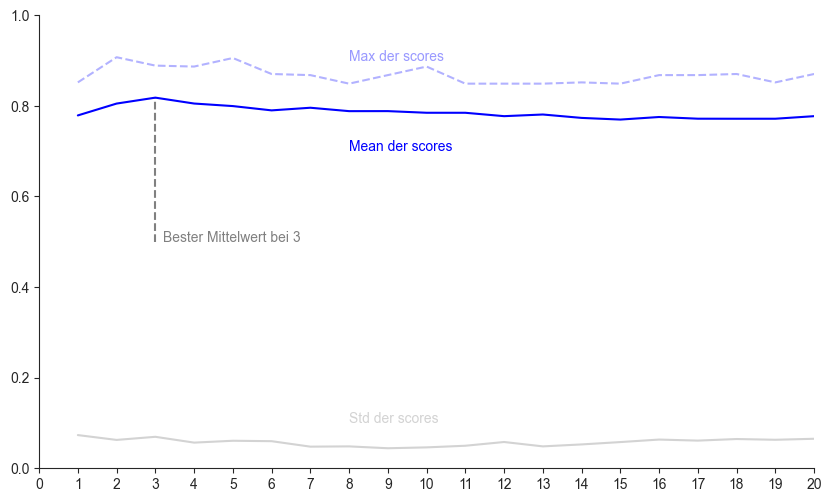

In [52]:
plt.plot([3, 3], [0.5, 0.8181], "--", color="grey")
plt.text(3.2, 0.5, "Bester Mittelwert bei 3", color="grey")
plt.plot([i[0] for i in results], [i[1].mean() for i in results], color="blue")
plt.plot([i[0] for i in results], [i[1].std() for i in results], color="lightgrey")
plt.plot(
    [i[0] for i in results],
    [i[1].max() for i in results],
    "--",
    color="blue",
    alpha=0.3,
)
plt.text(8, 0.7, "Mean der scores", color="blue")
plt.text(8, 0.9, "Max der scores", color="blue", alpha=0.4)
plt.text(8, 0.1, "Std der scores", color="lightgrey")
plt.xlim([0, 20])
plt.ylim([0, 1])
plt.xticks(np.arange(0, 21, step=1))
None